In [27]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

In [28]:
df = pd.read_csv("C:/Users/Tejasri mannuru/Downloads/Student Depression Dataset.csv")

In [29]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1
1,8,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0


In [30]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10458, 18)


In [31]:
print(df.columns)

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10458 entries, 0 to 10457
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     10458 non-null  int64  
 1   Gender                                 10458 non-null  object 
 2   Age                                    10458 non-null  int64  
 3   City                                   10458 non-null  object 
 4   Profession                             10458 non-null  object 
 5   Academic Pressure                      10458 non-null  int64  
 6   Work Pressure                          10458 non-null  int64  
 7   CGPA                                   10458 non-null  float64
 8   Study Satisfaction                     10458 non-null  int64  
 9   Job Satisfaction                       10458 non-null  int64  
 10  Sleep Duration                         10458 non-null  object 
 11  Di

In [33]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,10458.000000,10458.000000,10458.000000,10458.000000,10458.000000,10458.000000,10458.000000,10458.000000,10457.000000,10458.000000
mean,26360.192293,25.845095,3.133582,0.000478,7.666271,2.918244,0.000669,7.171065,3.131586,0.584720
std,15193.809716,4.904160,1.388362,0.048893,1.469556,1.360556,0.048891,3.694602,1.448654,0.492794
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,13346.750000,21.000000,2.000000,0.000000,6.280000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,26407.500000,26.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,39416.500000,30.000000,4.000000,0.000000,8.930000,4.000000,0.000000,10.000000,4.000000,1.000000
max,52988.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [34]:
# CHECK NULL VALUES
print(df.isnull().sum())

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         1
Family History of Mental Illness         0
Depression                               0
dtype: int64


# HANDLE MISSING VALUES
df.dropna(inplace=True)

In [35]:
print(df.isnull().sum())

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         1
Family History of Mental Illness         0
Depression                               0
dtype: int64


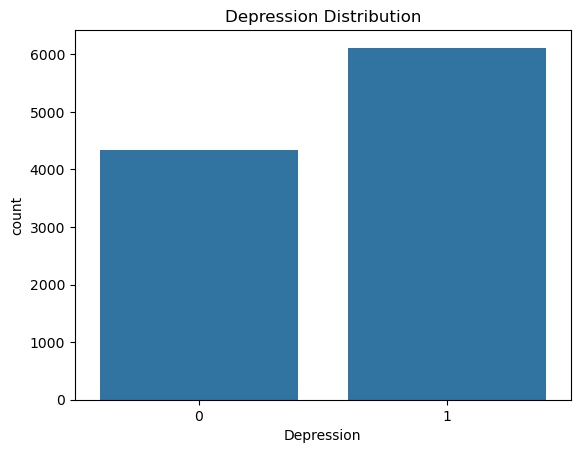

In [36]:
# 1) Distribution of Depression
sns.countplot(x='Depression', data=df)
plt.title("Depression Distribution")
plt.show()

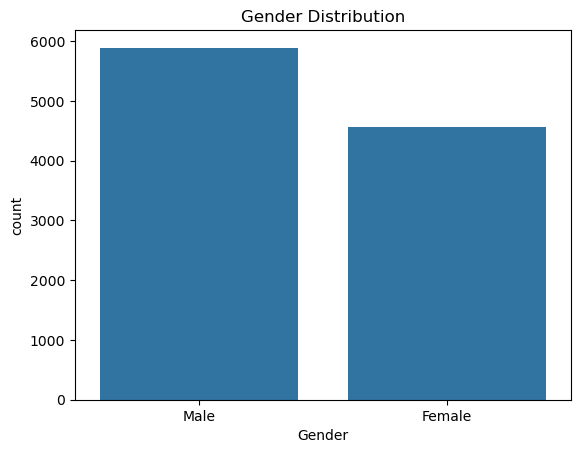

In [37]:
# 2) Gender Distribution
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

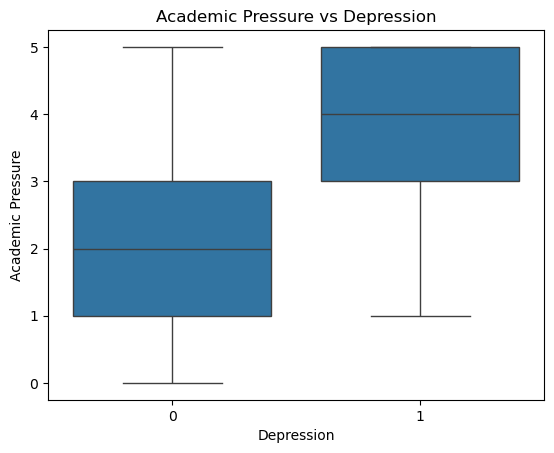

In [38]:
# 3) Academic Pressure vs Depression

sns.boxplot(x='Depression', y='Academic Pressure', data=df)
plt.title("Academic Pressure vs Depression")
plt.show()

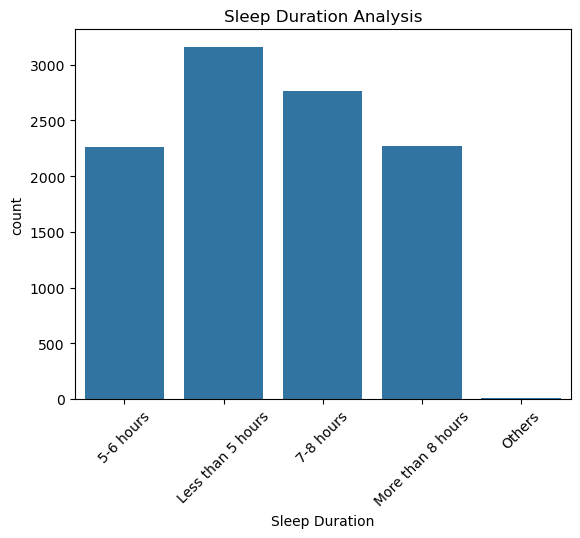

In [39]:
# 4) Sleep Duration Analysis

sns.countplot(x='Sleep Duration', data=df)
plt.xticks(rotation=45)
plt.title("Sleep Duration Analysis")
plt.show()

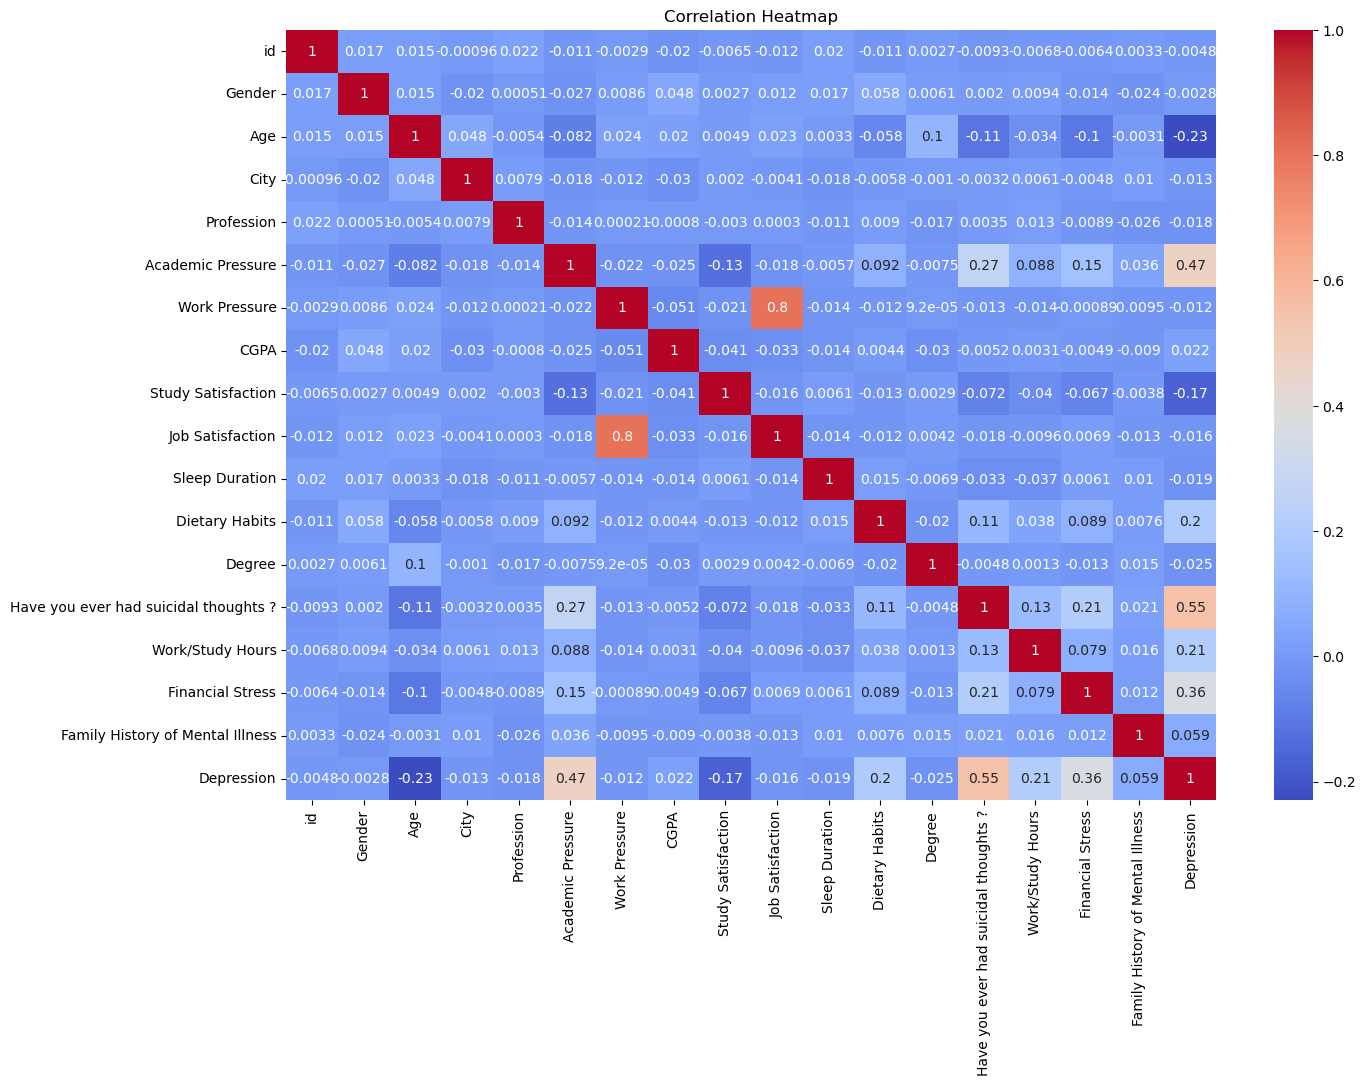

In [40]:
# 5) Correlation Heatmap
temp_df = df.copy()

le = LabelEncoder()

for col in temp_df.columns:
    if temp_df[col].dtype == 'object':
        temp_df[col] = le.fit_transform(temp_df[col])



plt.figure(figsize=(15,10))

sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [41]:
#Convert Categorical Columns

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,1,33,38,6,5,0,8.97,2,0,0,0,3,1,3,1.0,0,1
1,8,0,24,3,6,2,0,5.90,5,0,0,1,10,0,3,2.0,1,0
2,26,1,31,32,6,3,0,7.03,5,0,2,0,5,0,9,1.0,1,0
3,30,0,28,36,6,3,0,5.59,2,0,1,1,7,1,4,5.0,1,1
4,32,0,25,14,6,4,0,8.13,3,0,0,1,17,1,1,1.0,0,0


In [42]:
# FEATURES & TARGET

X = df.drop('Depression', axis=1)

y = df['Depression']

print(X.shape)
print(y.shape)

(10458, 17)
(10458,)


In [43]:
# SPLIT DATA

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8366, 17)
(2092, 17)


In [44]:


X_train = X_train.dropna()
X_test = X_test.dropna()



y_train = y_train[X_train.index]
y_test = y_test[X_test.index]



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



lr_model = LogisticRegression(max_iter=1000)


lr_model.fit(X_train, y_train)



lr_pred = lr_model.predict(X_test)


print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.8422562141491395


In [45]:
# 2) Decision Tree Classifier

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.760038240917782


In [46]:
# 3) Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8365200764818356


In [47]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.78      0.80       888
           1       0.84      0.88      0.86      1204

    accuracy                           0.84      2092
   macro avg       0.84      0.83      0.83      2092
weighted avg       0.84      0.84      0.84      2092



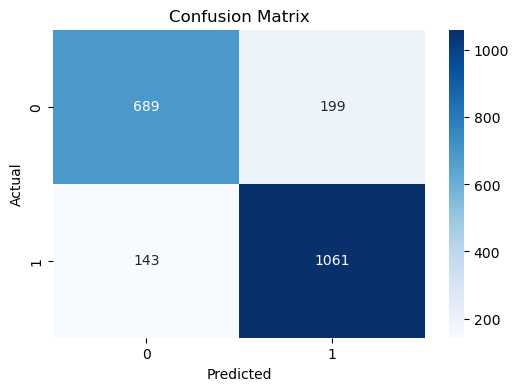

In [48]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

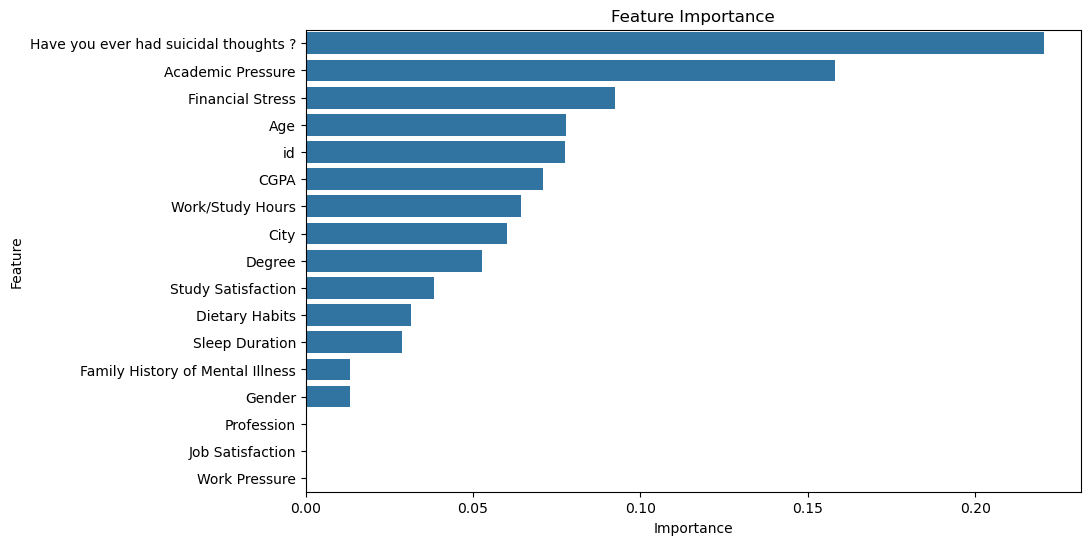

In [49]:


importance = rf_model.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)


plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df
)

plt.title("Feature Importance")

plt.show()

In [50]:

models = ['Logistic Regression',
          'Decision Tree',
          'Random Forest']

accuracy = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]

accuracy_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy
})

print(accuracy_df)

                 Model  Accuracy
0  Logistic Regression  0.842256
1        Decision Tree  0.760038
2        Random Forest  0.836520


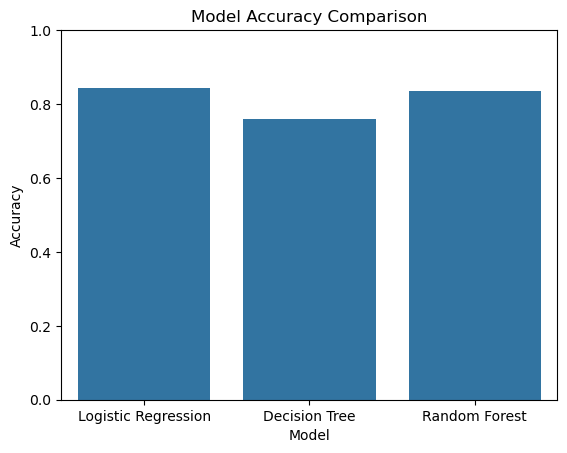

In [51]:

sns.barplot(
    x='Model',
    y='Accuracy',
    data=accuracy_df
)

plt.title("Model Accuracy Comparison")

plt.ylim(0,1)

plt.show()

In [52]:
import pickle

pickle.dump(rf_model,
            open('student_stress_model.pkl', 'wb'))

print("Model Saved Successfully")

Model Saved Successfully


In [53]:
X = df.drop(['Depression', 'id'], axis=1)

y = df['Depression']

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:

# NEW STUDENT DATA

new_student = pd.DataFrame({

    'Gender': [1],
    'Age': [20],
    'City': [5],
    'Profession': [2],
    'Academic Pressure': [5],
    'Work Pressure': [2],
    'CGPA': [7.5],
    'Study Satisfaction': [2],
    'Job Satisfaction': [3],
    'Sleep Duration': [1],
    'Dietary Habits': [2],
    'Degree': [1],
    'Have you ever had suicidal thoughts ?': [0],
    'Work/Study Hours': [10],
    'Financial Stress': [5],
    'Family History of Mental Illness': [1]

})



prediction = rf_model.predict(new_student)


if prediction[0] == 1:
    print("Student Has Depression")
else:
    print("Student Does Not Have Depression")

Student Has Depression


In [56]:

# NEW STUDENT DATA

new_student = pd.DataFrame({

    'Gender': [1],
    'Age': [20],
    'City': [5],
    'Profession': [2],
    'Academic Pressure': [0],
    'Work Pressure': [2],
    'CGPA': [7.5],
    'Study Satisfaction': [0],
    'Job Satisfaction': [0],
    'Sleep Duration': [8],
    'Dietary Habits': [0],
    'Degree': [1],
    'Have you ever had suicidal thoughts ?': [0],
    'Work/Study Hours': [10],
    'Financial Stress': [0],
    'Family History of Mental Illness': [1]

})

# Predict

prediction = rf_model.predict(new_student)

# Output

if prediction[0] == 1:
    print("Student Has Depression")
else:
    print("Student Does Not Have Depression")

Student Does Not Have Depression
